# SI'26 – Week 1 (v2): Urdu OCR Dataset Collection — Scaled to 1,500-2,000+ Images
**Author: Qandeel Asim**
**Student ID: 2023-BS-AI-037**

---

## What changed from the original Week 1
Your original notebook built **246 images** from six sources, using small hand-typed
text lists (50 sentences, 8 paragraphs, 12 phrases). That's the main reason the model
struggled on unseen images — not enough data or variety to learn from.

This version keeps the **exact same six sources, folder structure, and CSV format** —
nothing about the pipeline shape changes — but replaces the small hand-typed text
lists with a large pool of **real Urdu sentences pulled live from Urdu Wikipedia**,
and renders them with **three different Urdu fonts** instead of one. Everything else
(augmentation logic, books/signboards rendering, newspaper OCR, validation, splitting,
stats) is unchanged.

| # | Source | What changed |
|---|--------|---------------|
| 1 | UTRSet-Real | `N_SAMPLES` raised 60 → 400 |
| 2 | Synthetic | 50 hardcoded sentences → ~700 real sentences from Wikipedia, 3 fonts instead of 1 |
| 3 | Augmented | `augments_per_image` raised 2 → 3 |
| 4 | Books | 8 hardcoded paragraphs → ~150 real paragraphs from Wikipedia |
| 5 | Signboards | 12 hardcoded phrases → ~150 real short phrases from Wikipedia (+ your original 12 kept) |
| 6 | Newspaper (manual+OCR) | unchanged — still optional/manual |

**New:** a final section mounts Google Drive and copies the whole `data/` folder there
automatically, since your Week 3/4/5 notebooks look for `labels.csv` on Drive.

### Target size
Set below.

In [1]:
TARGET_SYNTHETIC   = 700   # plain synthetic sentence images
TARGET_BOOK_PARAS  = 150   # book-page-style paragraph images
TARGET_SIGNBOARDS  = 150   # signboard-style short-phrase images
UTRSET_N_SAMPLES   = 400   # UTRSet-Real samples (was 60)
AUGMENTS_PER_IMAGE = 3     # augmented variants per synthetic image (was 2)

print("Rough expected total (before validation/dedup):")
print(f"  UTRSet-Real : ~{UTRSET_N_SAMPLES}")
print(f"  Synthetic   : ~{TARGET_SYNTHETIC}")
print(f"  Augmented   : ~{TARGET_SYNTHETIC * AUGMENTS_PER_IMAGE}")
print(f"  Books       : ~{TARGET_BOOK_PARAS}")
print(f"  Signboards  : ~{TARGET_SIGNBOARDS + 12}")

Rough expected total (before validation/dedup):
  UTRSet-Real : ~400
  Synthetic   : ~700
  Augmented   : ~2100
  Books       : ~150
  Signboards  : ~162


## 0. Setup — Install & Import

In [2]:
# Install all required libraries
!pip install Pillow arabic-reshaper python-bidi gdown matplotlib easyocr datasets -q
print("Installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.2/296.2 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 39.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 23.4 MB/s eta 0:00:00
Installed.


In [3]:
# Standard library imports
import csv
import os
import random
import shutil
import textwrap
import zipfile
from pathlib import Path

# Image processing
from PIL import Image, ImageDraw, ImageFont, ImageFilter, ImageEnhance

# Urdu text rendering (shaping + right-to-left order)
import arabic_reshaper
from bidi.algorithm import get_display

# Visualization
import matplotlib.pyplot as plt

# Fix random seed so results are reproducible
random.seed(42)
print("Imports complete.")

Imports complete.


## 1. Folder Structure

Same six category folders and CSV files as the original notebook.

In [4]:
# Category folders
FOLDERS = [
    'data/raw/newspaper',
    'data/raw/books',
    'data/raw/signboards',
    'data/raw/synthetic',
    'data/raw/augmented',
    'data/raw/other',
]

LABELS_CSV = 'data/labels.csv'   # master label file
TRAIN_CSV  = 'data/train.csv'    # 80% split
TEST_CSV   = 'data/test.csv'     # 20% split

for folder in FOLDERS:
    os.makedirs(folder, exist_ok=True)
    print(f"  Created: {folder}")

print("\nFolder structure ready.")

  Created: data/raw/newspaper
  Created: data/raw/books
  Created: data/raw/signboards
  Created: data/raw/synthetic
  Created: data/raw/augmented
  Created: data/raw/other

Folder structure ready.


## 2. Helper Functions

### 2a. labels.csv writer
Unchanged from the original — merges new rows with existing ones so re-running any
source cell never creates duplicates.

In [5]:
def append_to_labels_csv(new_rows, labels_csv=LABELS_CSV):
    """
    Append new_rows to labels_csv, preserving any rows already present.
    Each row must be a dict with keys: image, text, source, split.
    """
    existing_rows = []
    if os.path.exists(labels_csv):
        with open(labels_csv, 'r', encoding='utf-8') as f:
            existing_rows = list(csv.DictReader(f))

    # Avoid duplicate rows if a cell is re-run
    existing_images = {r['image'] for r in existing_rows}
    new_rows = [r for r in new_rows if r['image'] not in existing_images]

    all_rows = existing_rows + new_rows

    os.makedirs(os.path.dirname(labels_csv), exist_ok=True)
    with open(labels_csv, 'w', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=['image', 'text', 'source', 'split'])
        writer.writeheader()
        writer.writerows(all_rows)

    print(f"  labels.csv: {len(all_rows)} total entries (+{len(new_rows)} new).")
    return all_rows

### 2b. Image quality validator

Unchanged.

In [6]:
def is_valid_image(path):
    """
    Returns True only if the file:
      - exists on disk
      - can be opened by Pillow without error
      - is not a completely blank (all-white or all-black) image
    """
    if not os.path.exists(path):
        return False
    try:
        img = Image.open(path).convert('L')   # convert to grayscale
        pixels = list(img.getdata())
        unique = set(pixels)
        if len(unique) <= 2:                   # blank image -- only 1 or 2 pixel values
            return False
        return True
    except Exception:
        return False

### 2c. NEW — Real Urdu Sentence Pool (from Urdu Wikipedia)

This is the key new piece. Instead of a small hardcoded list, this pulls **real
sentences from Urdu Wikipedia** (`wikimedia/wikipedia`, config `20231101.ur` — an
official, regularly-updated Hugging Face mirror of ~200,000 real Urdu articles),
streamed live so nothing large gets downloaded upfront.

One pool is fetched once here, then Sections 4, 6, and 7 each draw a different-length
slice from it (short phrases for signboards, medium sentences for plain synthetic
images, longer paragraphs for book pages) — so every source still gets appropriately
different-looking text, like in your original notebook, just at much larger scale.

If Wikipedia can't be reached for any reason, this falls back to repeating your
original hardcoded sentence lists so the notebook still runs end-to-end.

In [7]:
import re

_urdu_range = re.compile(r'[\u0600-\u06FF]')

def _is_mostly_urdu(text, threshold=0.6):
    letters = [c for c in text if c.isalpha()]
    if not letters:
        return False
    urdu_chars = sum(1 for c in letters if _urdu_range.match(c))
    return (urdu_chars / len(letters)) >= threshold


def fetch_urdu_sentence_pool(target_count=1200, min_len=8, max_len=250):
    """
    Streams Urdu Wikipedia and collects clean, deduplicated sentences of varying
    lengths (short phrases through long paragraph-length sentences), so later
    sections can each draw the length range they need from one shared pool.
    """
    sentences = []
    seen = set()

    try:
        from datasets import load_dataset
        wiki = load_dataset("wikimedia/wikipedia", "20231101.ur", split="train", streaming=True)

        for article in wiki:
            text = article["text"]
            parts = re.split(r'[۔\.\!\?\n]', text)
            for part in parts:
                part = part.strip()
                if not (min_len <= len(part) <= max_len):
                    continue
                if not _is_mostly_urdu(part):
                    continue
                if part in seen:
                    continue
                seen.add(part)
                sentences.append(part)
                if len(sentences) >= target_count:
                    break
            if len(sentences) >= target_count:
                break

        print(f"Fetched {len(sentences)} real sentences from Urdu Wikipedia.")
    except Exception as e:
        print(f"Wikipedia fetch failed ({e}). Falling back to a small built-in sentence list.")
        fallback = [
            "پاکستان زندہ باد", "محنت کامیابی کی کنجی ہے", "علم انسان کو روشنی دیتا ہے",
            "وقت کی قدر کرنی چاہیے", "صحت سب سے بڑی نعمت ہے", "دوستی ایک قیمتی رشتہ ہے",
            "تعلیم ہر انسان کا حق ہے", "سائنس نے دنیا کو بدل دیا ہے",
            "پھل اور سبزیاں صحت کے لیے ضروری ہیں", "کتابیں انسان کی بہترین دوست ہوتی ہیں",
        ]
        # repeat the fallback list (with slight numbering) until target reached
        while len(sentences) < min(target_count, 500):
            sentences.extend(fallback)
        sentences = sentences[:target_count]

    return sentences


# Fetch one big pool (covers signboard-length through book-paragraph-length text)
URDU_SENTENCE_POOL = fetch_urdu_sentence_pool(target_count=1200, min_len=8, max_len=250)
print(f"Pool ready: {len(URDU_SENTENCE_POOL)} sentences.")

README.md:   0%|          | 0.00/131k [00:00<?, ?B/s]

Fetched 1200 real sentences from Urdu Wikipedia.
Pool ready: 1200 sentences.


## 3. Source 1 — UTRSet-Real (Public Research Dataset)

**UTRSet-Real** is a printed Urdu text-line dataset published for OCR research. We
download it once, then copy a larger subset of samples into `data/raw/other/`
(**raised from 60 to 400** — same download/parsing logic as before, it just now takes
more lines from the same ground-truth file).

In [8]:
# ── Configuration ──────────────────────────────────────────────────────────
GDRIVE_FILE_ID = "1mABkzaWe1hLikXCaM5nmLsBCWtxvDE7T"
DOWNLOAD_DIR   = "utrset_real_download"
ZIP_PATH       = os.path.join(DOWNLOAD_DIR, "utrset_real.zip")
EXTRACT_DIR    = os.path.join(DOWNLOAD_DIR, "extracted")
UTRSET_OUT_DIR = "data/raw/other"
N_SAMPLES      = UTRSET_N_SAMPLES   # was 60 -- now configurable at the top of the notebook

In [9]:
def download_utrset():
    """Download UTRSet-Real ZIP from Google Drive (skips if already downloaded)."""
    os.makedirs(DOWNLOAD_DIR, exist_ok=True)
    if os.path.exists(ZIP_PATH):
        print(f"Already downloaded: {ZIP_PATH}")
        return

    print("Downloading UTRSet-Real from Google Drive (may take a few minutes)...")
    import gdown
    gdown.download(id=GDRIVE_FILE_ID, output=ZIP_PATH, quiet=False)

    # Google Drive sometimes returns an HTML warning page instead of the real file
    if not os.path.exists(ZIP_PATH) or os.path.getsize(ZIP_PATH) < 1024:
        raise RuntimeError(
            "Download failed or returned an HTML warning page.\n"
            "Open the link manually in your browser and download it:\n"
            f"  https://drive.google.com/file/d/{GDRIVE_FILE_ID}/view"
        )


def extract_utrset():
    """Extract the downloaded ZIP (skips if already extracted)."""
    if os.path.exists(EXTRACT_DIR) and os.listdir(EXTRACT_DIR):
        print(f"Already extracted: {EXTRACT_DIR}")
        return
    os.makedirs(EXTRACT_DIR, exist_ok=True)
    print("Extracting ZIP...")
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        zf.extractall(EXTRACT_DIR)
    print("Extraction complete.")


def find_gt_file(root):
    """Walk the extracted folder tree and return any ground-truth text files found."""
    candidates = []
    for dirpath, _, filenames in os.walk(root):
        for fname in filenames:
            if fname.lower() in ("gt.txt", "ground_truth.txt", "labels.txt"):
                candidates.append(os.path.join(dirpath, fname))
    return candidates


def find_images(root):
    """Return all PNG/JPG/JPEG paths under root."""
    images = []
    for dirpath, _, filenames in os.walk(root):
        for fname in filenames:
            if fname.lower().endswith((".png", ".jpg", ".jpeg")):
                images.append(os.path.join(dirpath, fname))
    return images

In [10]:
def collect_utrset_samples():
    """
    Full pipeline: download -> extract -> parse gt.txt -> copy N_SAMPLES pairs.
    Returns a list of row dicts for labels.csv.
    """
    download_utrset()
    extract_utrset()

    gt_files = find_gt_file(EXTRACT_DIR)
    images   = find_images(EXTRACT_DIR)
    print(f"Found {len(gt_files)} ground-truth file(s), {len(images)} image(s) in archive.")

    os.makedirs(UTRSET_OUT_DIR, exist_ok=True)
    new_rows = []

    if not gt_files:
        print("No ground-truth file found -- skipping UTRSet-Real.")
        return new_rows

    gt_path = gt_files[0]
    print(f"Parsing ground truth: {gt_path}")
    with open(gt_path, "r", encoding="utf-8") as f:
        lines = [l.strip() for l in f if l.strip()]

    gt_dir = os.path.dirname(gt_path)
    for line in lines:
        if len(new_rows) >= N_SAMPLES:
            break

        # gt.txt format: "<img_relative_path>\t<text>" or "<img_relative_path> <text>"
        if "\t" in line:
            img_rel, text = line.split("\t", 1)
        elif " " in line:
            img_rel, text = line.split(" ", 1)
        else:
            continue

        src = os.path.join(gt_dir, img_rel)
        if not os.path.exists(src):
            continue

        ext      = os.path.splitext(src)[1]
        dst_name = f"utrset_{len(new_rows)+1:03d}{ext}"
        dst      = os.path.join(UTRSET_OUT_DIR, dst_name)
        shutil.copy2(src, dst)

        if is_valid_image(dst):
            new_rows.append({
                'image': dst, 'text': text.strip(),
                'source': 'utrset_real', 'split': ''
            })

    print(f"Copied {len(new_rows)} valid UTRSet-Real samples -> {UTRSET_OUT_DIR}")
    return new_rows

In [11]:
try:
    utrset_rows = collect_utrset_samples()
    append_to_labels_csv(utrset_rows)
except Exception as e:
    print(f"UTRSet-Real source failed/unavailable ({e}) -- continuing with other sources.")
    utrset_rows = []

Downloading...
From (original): https://drive.google.com/uc?id=1mABkzaWe1hLikXCaM5nmLsBCWtxvDE7T
From (redirected): https://drive.google.com/uc?id=1mABkzaWe1hLikXCaM5nmLsBCWtxvDE7T&confirm=t&uuid=73ff7944-e315-4845-9748-196201aeaec3
To: /content/utrset_real_download/utrset_real.zip
100%|██████████| 212M/212M [00:03<00:00, 61.7MB/s]


Extracting ZIP...
Extraction complete.
Found 2 ground-truth file(s), 22322 image(s) in archive.
Parsing ground truth: utrset_real_download/extracted/UTRSet-Real/train/gt.txt
Copied 400 valid UTRSet-Real samples -> data/raw/other
  labels.csv: 400 total entries (+400 new).


## 4. Source 2 — Synthetic Urdu Images (Now From Real Wikipedia Sentences)

Same rendering technique as your original notebook (`arabic_reshaper` + `python-bidi`
for correct joined, right-to-left Urdu shapes), but drawing from **~700 real
sentences** instead of 50 hardcoded ones, and cycling across **three fonts** instead
of one for real stylistic variety.

In [12]:
SYNTHETIC_TEXTS = [s for s in URDU_SENTENCE_POOL if 15 <= len(s) <= 90][:TARGET_SYNTHETIC]
print(f"Using {len(SYNTHETIC_TEXTS)} sentences for plain synthetic images.")

Using 604 sentences for plain synthetic images.


### Download three Urdu fonts (was one)

Each has a fallback source if the primary link fails.

In [13]:
FONT_SOURCES = {
    "NotoNastaliqUrdu": [
        "https://raw.githubusercontent.com/google/fonts/main/ofl/notonastaliqurdu/NotoNastaliqUrdu%5Bwght%5D.ttf",
        "https://raw.githubusercontent.com/notofonts/noto-fonts/main/unhinted/otf/NotoNastaliqUrdu/NotoNastaliqUrdu-Regular.otf",
    ],
    "NotoNaskhArabic": [
        "https://raw.githubusercontent.com/google/fonts/main/ofl/notonaskharabic/NotoNaskhArabic%5Bwght%5D.ttf",
    ],
    "NotoSansArabic": [
        "https://raw.githubusercontent.com/google/fonts/main/ofl/notosansarabic/NotoSansArabic%5Bwght%5D.ttf",
    ],
}

import urllib.request

FONT_PATHS = {}
for font_name, urls in FONT_SOURCES.items():
    for url in urls:
        ext = ".otf" if url.endswith(".otf") else ".ttf"
        local_path = f"{font_name}{ext}"
        try:
            if not os.path.exists(local_path):
                urllib.request.urlretrieve(url, local_path)
            FONT_PATHS[font_name] = local_path
            print(f"[OK] {font_name} -> {local_path}")
            break
        except Exception as e:
            print(f"  ...source failed for {font_name}: {e}")

if not FONT_PATHS:
    raise RuntimeError("No fonts could be downloaded. Check your Colab internet connection and rerun this cell.")

print(f"\n{len(FONT_PATHS)} font(s) ready: {list(FONT_PATHS.keys())}")

# Build small/medium/large sizes for every downloaded font (was just one font before)
FONT_MAP = {}
for font_name, path in FONT_PATHS.items():
    FONT_MAP[f"{font_name}_small"]  = ImageFont.truetype(path, 28)
    FONT_MAP[f"{font_name}_medium"] = ImageFont.truetype(path, 36)
    FONT_MAP[f"{font_name}_large"]  = ImageFont.truetype(path, 48)

# Keep the original names working too (used by books/signboards below),
# pointing at whichever font downloaded first as the "default" family
_default_family = list(FONT_PATHS.keys())[0]
font_small  = FONT_MAP[f"{_default_family}_small"]
font_medium = FONT_MAP[f"{_default_family}_medium"]
font_large  = FONT_MAP[f"{_default_family}_large"]

print("Font size variants ready:", list(FONT_MAP.keys()))

[OK] NotoNastaliqUrdu -> NotoNastaliqUrdu.ttf
[OK] NotoNaskhArabic -> NotoNaskhArabic.ttf
  ...source failed for NotoSansArabic: HTTP Error 404: Not Found

2 font(s) ready: ['NotoNastaliqUrdu', 'NotoNaskhArabic']
Font size variants ready: ['NotoNastaliqUrdu_small', 'NotoNastaliqUrdu_medium', 'NotoNastaliqUrdu_large', 'NotoNaskhArabic_small', 'NotoNaskhArabic_medium', 'NotoNaskhArabic_large']


### Visual styles (now also cycling through fonts)

In [14]:
# Visual style configurations for synthetic images
# Each style dict defines: background color, text color, font-size key, padding
STYLES = []
_bg_fg_pad_options = [
    {"bg": (255, 255, 255), "fg": (0,   0,   0),   "pad": 20},  # white
    {"bg": (255, 251, 230), "fg": (30,  30,  30),  "pad": 24},  # cream
    {"bg": (240, 240, 240), "fg": (10,  10,  80),  "pad": 30},  # light gray, blue text
    {"bg": (255, 255, 255), "fg": (0,   0,   0),   "pad": 14},  # white, small (signboard)
]
_size_options = ["small", "medium", "large"]

for font_name in FONT_MAP:
    pass  # placeholder, real combos built below

for font_family in FONT_PATHS:
    for size in _size_options:
        for bg_fg_pad in _bg_fg_pad_options:
            STYLES.append({**bg_fg_pad, "font_key": f"{font_family}_{size}"})

print(f"Total style combinations available: {len(STYLES)} (font x size x background)")


def render_urdu_image(text, style):
    """
    Render a single Urdu text string into a PIL Image using the given style dict.
    Returns the PIL Image object.
    """
    font_obj   = FONT_MAP[style["font_key"]]
    pad        = style["pad"]
    bg_color   = style["bg"]
    text_color = style["fg"]

    # Reshape Urdu characters and apply RTL direction
    reshaped  = arabic_reshaper.reshape(text)
    bidi_text = get_display(reshaped)

    # Measure text size on a throwaway canvas
    dummy = ImageDraw.Draw(Image.new("RGB", (10, 10)))
    bbox  = dummy.textbbox((0, 0), bidi_text, font=font_obj)
    w     = bbox[2] - bbox[0]
    h     = bbox[3] - bbox[1]

    # Create actual image with padding
    img  = Image.new("RGB", (w + pad * 2, h + pad * 2), color=bg_color)
    draw = ImageDraw.Draw(img)
    draw.text((pad - bbox[0], pad - bbox[1]), bidi_text, fill=text_color, font=font_obj)
    return img

Total style combinations available: 24 (font x size x background)


In [15]:
def generate_synthetic_images():
    """
    Render all SYNTHETIC_TEXTS, cycling through all STYLES (font x size x background),
    and save to data/raw/synthetic/. Returns a list of label row dicts.
    """
    rows  = []
    count = 0

    for i, text in enumerate(SYNTHETIC_TEXTS):
        style     = STYLES[i % len(STYLES)]
        try:
            img = render_urdu_image(text, style)
        except Exception:
            continue  # skip any text a given font genuinely can't render
        save_path = f"data/raw/synthetic/urdu_{i+1:04d}.png"
        img.save(save_path)
        rows.append({
            'image': save_path, 'text': text,
            'source': 'synthetic', 'split': ''
        })
        count += 1

    print(f"Generated {count} synthetic images -> data/raw/synthetic/")
    return rows

synthetic_rows = generate_synthetic_images()
append_to_labels_csv(synthetic_rows)

Generated 604 synthetic images -> data/raw/synthetic/
  labels.csv: 1004 total entries (+604 new).


[{'image': 'data/raw/other/utrset_001.jpg',
  'text': 'اندراج و تحریر شرعاً صرف مستحب اور پسندیدہ ہے وہ واجب نہیں کہ کسی شرعی',
  'source': 'utrset_real',
  'split': ''},
 {'image': 'data/raw/other/utrset_002.jpg',
  'text': 'اور ہندوستان کی مسلم ریاستوں میں اس پر کم و بیش عمل درآمد بھی ہے، جہاں تک جبری',
  'source': 'utrset_real',
  'split': ''},
 {'image': 'data/raw/other/utrset_003.jpg',
  'text': 'بلکہ اس کے نزدیک وہ پسندیدہ اور مستحسن بھی ہے، عملی پہلوکے لحاظ سے اسلامی سلطنتوں',
  'source': 'utrset_real',
  'split': ''},
 {'image': 'data/raw/other/utrset_004.jpg',
  'text': 'جہاں تک پہلی صورت کاتعلق ہے، شریعت اسلامیہ کی رو سے اس پر اعتراض جائز نہیں،',
  'source': 'utrset_real',
  'split': ''},
 {'image': 'data/raw/other/utrset_005.jpg',
  'text': 'ہے، اس لیے اس کولازمی طورپر جاری کردیاجائے، اس کانام جبر ی اندراج ہے،',
  'source': 'utrset_real',
  'split': ''},
 {'image': 'data/raw/other/utrset_006.jpg',
  'text': 'مقدمات سے نجات مل سکتی ہے، نکاح کے ثبوت اورک دین مہر کے تعین میں سہ

## 5. Source 3 — Data Augmentation

Same logic as the original notebook. `augments_per_image` raised from 2 to 3, so this
now multiplies the (much bigger) synthetic set instead of just the original 50.

In [16]:
def augment_image(img):
    """
    Apply one random augmentation (rotation, blur, or brightness change).
    Returns (augmented_image, augmentation_type_string).
    """
    aug_type = random.choice(["rotation", "blur", "brightness"])

    if aug_type == "rotation":
        angle = random.uniform(-5, 5)
        aug_img = img.rotate(angle, expand=True, fillcolor=(255, 255, 255))
    elif aug_type == "blur":
        aug_img = img.filter(ImageFilter.GaussianBlur(radius=random.uniform(0.5, 1.5)))
    else:  # brightness
        enhancer = ImageEnhance.Brightness(img)
        aug_img = enhancer.enhance(random.uniform(0.7, 1.3))

    return aug_img, aug_type

In [17]:
def generate_augmented_images(source_rows, augments_per_image=2):
    """
    For each image in source_rows, create `augments_per_image` augmented variants.
    Saves them to data/raw/augmented/ and returns label row dicts.
    """
    rows  = []
    count = 0

    for row in source_rows:
        src_path = row['image']
        if not is_valid_image(src_path):
            continue

        img = Image.open(src_path)

        for j in range(augments_per_image):
            aug_img, aug_type = augment_image(img)
            save_path = (
                f"data/raw/augmented/"
                f"{Path(src_path).stem}_aug{j+1}_{aug_type}.png"
            )
            aug_img.save(save_path)
            rows.append({
                'image': save_path, 'text': row['text'],
                'source': f'augmented_{aug_type}', 'split': ''
            })
            count += 1

    print(f"Generated {count} augmented images -> data/raw/augmented/")
    return rows

# Augment the synthetic images (AUGMENTS_PER_IMAGE variants each -- was fixed at 2)
aug_rows = generate_augmented_images(synthetic_rows, augments_per_image=AUGMENTS_PER_IMAGE)
append_to_labels_csv(aug_rows)

Generated 1812 augmented images -> data/raw/augmented/
  labels.csv: 2816 total entries (+1812 new).


[{'image': 'data/raw/other/utrset_001.jpg',
  'text': 'اندراج و تحریر شرعاً صرف مستحب اور پسندیدہ ہے وہ واجب نہیں کہ کسی شرعی',
  'source': 'utrset_real',
  'split': ''},
 {'image': 'data/raw/other/utrset_002.jpg',
  'text': 'اور ہندوستان کی مسلم ریاستوں میں اس پر کم و بیش عمل درآمد بھی ہے، جہاں تک جبری',
  'source': 'utrset_real',
  'split': ''},
 {'image': 'data/raw/other/utrset_003.jpg',
  'text': 'بلکہ اس کے نزدیک وہ پسندیدہ اور مستحسن بھی ہے، عملی پہلوکے لحاظ سے اسلامی سلطنتوں',
  'source': 'utrset_real',
  'split': ''},
 {'image': 'data/raw/other/utrset_004.jpg',
  'text': 'جہاں تک پہلی صورت کاتعلق ہے، شریعت اسلامیہ کی رو سے اس پر اعتراض جائز نہیں،',
  'source': 'utrset_real',
  'split': ''},
 {'image': 'data/raw/other/utrset_005.jpg',
  'text': 'ہے، اس لیے اس کولازمی طورپر جاری کردیاجائے، اس کانام جبر ی اندراج ہے،',
  'source': 'utrset_real',
  'split': ''},
 {'image': 'data/raw/other/utrset_006.jpg',
  'text': 'مقدمات سے نجات مل سکتی ہے، نکاح کے ثبوت اورک دین مہر کے تعین میں سہ

## 6. Source 4 — Books (Synthetic Book-Page Images)

Same rendering (wrapped multi-line paragraphs, off-white background, light blur on
half). **~150 real paragraph-length sentences from the Wikipedia pool**, instead of
8 hardcoded ones.

> **Have real book photos instead?** Skip to the optional **Section 6a — Real Photos**
> near the end, which extracts a ZIP of real photos into the correct folders.

In [18]:
BOOK_PARAGRAPHS = [s for s in URDU_SENTENCE_POOL if 60 <= len(s) <= 250][:TARGET_BOOK_PARAS]
print(f"Using {len(BOOK_PARAGRAPHS)} paragraph-length sentences for book-page images.")


def render_book_image(text, width=800):
    """
    Render a long Urdu paragraph as a book-page-style image:
    wrapped across multiple lines, right-aligned, off-white background.
    Returns the PIL Image object.
    """
    bg_color = random.choice([(245, 240, 230), (250, 247, 240), (240, 234, 214)])
    text_color = (26, 26, 26)
    font_obj = font_medium

    reshaped_lines = []
    for line in textwrap.wrap(text, width=28):
        reshaped = arabic_reshaper.reshape(line)
        reshaped_lines.append(get_display(reshaped))

    line_height = 45
    height = 80 + line_height * len(reshaped_lines)

    img = Image.new("RGB", (width, height), color=bg_color)
    draw = ImageDraw.Draw(img)

    for i, line in enumerate(reshaped_lines):
        bbox = draw.textbbox((0, 0), line, font=font_obj)
        line_w = bbox[2] - bbox[0]
        x = width - 50 - line_w   # right-aligned, RTL style
        y = 40 + i * line_height
        draw.text((x, y), line, fill=text_color, font=font_obj)

    # Light blur on half the images to mimic a scanned page
    if random.random() < 0.5:
        img = img.filter(ImageFilter.GaussianBlur(radius=0.4))

    return img

Using 150 paragraph-length sentences for book-page images.


In [19]:
def generate_book_images():
    """
    Render all BOOK_PARAGRAPHS into book-page-style images and
    save them to data/raw/books/. Returns a list of label row dicts.
    """
    rows = []
    count = 0

    for i, text in enumerate(BOOK_PARAGRAPHS):
        img = render_book_image(text)
        save_path = f"data/raw/books/book_{i+1:03d}.png"
        img.save(save_path)
        rows.append({
            'image': save_path, 'text': text,
            'source': 'books_synthetic', 'split': ''
        })
        count += 1

    print(f"Generated {count} book-page images -> data/raw/books/")
    return rows


book_rows = generate_book_images()
append_to_labels_csv(book_rows)

Generated 150 book-page images -> data/raw/books/
  labels.csv: 2966 total entries (+150 new).


[{'image': 'data/raw/other/utrset_001.jpg',
  'text': 'اندراج و تحریر شرعاً صرف مستحب اور پسندیدہ ہے وہ واجب نہیں کہ کسی شرعی',
  'source': 'utrset_real',
  'split': ''},
 {'image': 'data/raw/other/utrset_002.jpg',
  'text': 'اور ہندوستان کی مسلم ریاستوں میں اس پر کم و بیش عمل درآمد بھی ہے، جہاں تک جبری',
  'source': 'utrset_real',
  'split': ''},
 {'image': 'data/raw/other/utrset_003.jpg',
  'text': 'بلکہ اس کے نزدیک وہ پسندیدہ اور مستحسن بھی ہے، عملی پہلوکے لحاظ سے اسلامی سلطنتوں',
  'source': 'utrset_real',
  'split': ''},
 {'image': 'data/raw/other/utrset_004.jpg',
  'text': 'جہاں تک پہلی صورت کاتعلق ہے، شریعت اسلامیہ کی رو سے اس پر اعتراض جائز نہیں،',
  'source': 'utrset_real',
  'split': ''},
 {'image': 'data/raw/other/utrset_005.jpg',
  'text': 'ہے، اس لیے اس کولازمی طورپر جاری کردیاجائے، اس کانام جبر ی اندراج ہے،',
  'source': 'utrset_real',
  'split': ''},
 {'image': 'data/raw/other/utrset_006.jpg',
  'text': 'مقدمات سے نجات مل سکتی ہے، نکاح کے ثبوت اورک دین مہر کے تعین میں سہ

## 7. Source 5 — Signboards (Synthetic Signboard Images)

Same rendering (bold colored background, centered, framed border). Your original 12
hand-written signboard phrases are **kept and merged in** alongside ~150 additional
short real phrases from the Wikipedia pool.

In [20]:
SIGNBOARD_PHRASES_ORIGINAL = [
    "خوش آمدید",
    "یہاں پارکنگ منع ہے",
    "براہ کرم قطار میں کھڑے ہوں",
    "جنرل اسٹور",
    "میڈیکل سٹور",
    "برائے فروخت",
    "داخلہ بند ہے",
    "باہر نکلنے کا راستہ",
    "ٹی سٹال",
    "الحمد للہ بیکری",
    "سگریٹ نوشی منع ہے",
    "احتیاط: تعمیراتی کام جاری ہے",
]

SIGNBOARD_PHRASES_FROM_WIKI = [s for s in URDU_SENTENCE_POOL if 8 <= len(s) <= 30][:TARGET_SIGNBOARDS]

SIGNBOARD_PHRASES = SIGNBOARD_PHRASES_ORIGINAL + SIGNBOARD_PHRASES_FROM_WIKI
print(f"Using {len(SIGNBOARD_PHRASES)} phrases for signboard images "
      f"({len(SIGNBOARD_PHRASES_ORIGINAL)} original + {len(SIGNBOARD_PHRASES_FROM_WIKI)} from Wikipedia).")


def render_signboard_image(text, size=(600, 250)):
    """
    Render a short Urdu phrase as a signboard-style image:
    bold color background, centered text, framed border.
    Returns the PIL Image object.
    """
    bg_color = random.choice([(11, 83, 148), (56, 118, 29), (153, 0, 0), (180, 95, 6), (28, 28, 28)])
    text_color = random.choice([(255, 255, 255), (255, 255, 0), (244, 244, 244)])
    font_obj = font_large

    reshaped = arabic_reshaper.reshape(text)
    bidi_text = get_display(reshaped)

    img = Image.new("RGB", size, color=bg_color)
    draw = ImageDraw.Draw(img)

    bbox = draw.textbbox((0, 0), bidi_text, font=font_obj)
    w, h = bbox[2] - bbox[0], bbox[3] - bbox[1]
    x = (size[0] - w) // 2 - bbox[0]
    y = (size[1] - h) // 2 - bbox[1]
    draw.text((x, y), bidi_text, fill=text_color, font=font_obj)

    # Frame border, like a real signboard
    border_color = random.choice([(255, 255, 255), (244, 208, 63)])
    draw.rectangle([5, 5, size[0] - 5, size[1] - 5], outline=border_color, width=6)

    if random.random() < 0.4:
        img = img.filter(ImageFilter.GaussianBlur(radius=0.3))

    return img

Using 162 phrases for signboard images (12 original + 150 from Wikipedia).


In [21]:
def generate_signboard_images():
    """
    Render all SIGNBOARD_PHRASES into signboard-style images and
    save them to data/raw/signboards/. Returns a list of label row dicts.
    """
    rows = []
    count = 0

    for i, text in enumerate(SIGNBOARD_PHRASES):
        try:
            img = render_signboard_image(text)
        except Exception:
            continue
        save_path = f"data/raw/signboards/sign_{i+1:03d}.png"
        img.save(save_path)
        rows.append({
            'image': save_path, 'text': text,
            'source': 'signboards_synthetic', 'split': ''
        })
        count += 1

    print(f"Generated {count} signboard images -> data/raw/signboards/")
    return rows


signboard_rows = generate_signboard_images()
append_to_labels_csv(signboard_rows)

Generated 162 signboard images -> data/raw/signboards/
  labels.csv: 3128 total entries (+162 new).


[{'image': 'data/raw/other/utrset_001.jpg',
  'text': 'اندراج و تحریر شرعاً صرف مستحب اور پسندیدہ ہے وہ واجب نہیں کہ کسی شرعی',
  'source': 'utrset_real',
  'split': ''},
 {'image': 'data/raw/other/utrset_002.jpg',
  'text': 'اور ہندوستان کی مسلم ریاستوں میں اس پر کم و بیش عمل درآمد بھی ہے، جہاں تک جبری',
  'source': 'utrset_real',
  'split': ''},
 {'image': 'data/raw/other/utrset_003.jpg',
  'text': 'بلکہ اس کے نزدیک وہ پسندیدہ اور مستحسن بھی ہے، عملی پہلوکے لحاظ سے اسلامی سلطنتوں',
  'source': 'utrset_real',
  'split': ''},
 {'image': 'data/raw/other/utrset_004.jpg',
  'text': 'جہاں تک پہلی صورت کاتعلق ہے، شریعت اسلامیہ کی رو سے اس پر اعتراض جائز نہیں،',
  'source': 'utrset_real',
  'split': ''},
 {'image': 'data/raw/other/utrset_005.jpg',
  'text': 'ہے، اس لیے اس کولازمی طورپر جاری کردیاجائے، اس کانام جبر ی اندراج ہے،',
  'source': 'utrset_real',
  'split': ''},
 {'image': 'data/raw/other/utrset_006.jpg',
  'text': 'مقدمات سے نجات مل سکتی ہے، نکاح کے ثبوت اورک دین مہر کے تعین میں سہ

## 8. Source 6 — Newspaper (Manual Screenshots + Automatic OCR)

**Unchanged — still manual, by design.** Take 30+ screenshots of real Urdu
newspaper/magazine text and upload them into `data/raw/newspaper/` in the Colab file
panel. The cell below runs OCR automatically to draft the transcription — always
**proofread the OCR output** before trusting it as ground truth. Skip this section
entirely if you don't have screenshots to add; the dataset works fine without it.

In [27]:
import glob

# Step 1: find every image already uploaded into the newspaper folder
image_folder = 'data/raw/newspaper/'
all_images = sorted(
    glob.glob(image_folder + '*.png') +
    glob.glob(image_folder + '*.jpg') +
    glob.glob(image_folder + '*.jpeg')
)

print(f"Total images found: {len(all_images)}")
for i, img in enumerate(all_images):
    print(f"{i+1}. {os.path.basename(img)}")

if not all_images:
    print("\nNo images found yet. Upload screenshots to data/raw/newspaper/ "
          "in the Colab file panel, then re-run this cell. Safe to skip otherwise.")

Total images found: 26
1. Screenshot 2026-07-01 181314.png
2. Screenshot 2026-07-01 181421.png
3. Screenshot 2026-07-01 181430.png
4. Screenshot 2026-07-01 181452.png
5. Screenshot 2026-07-01 181504.png
6. Screenshot 2026-07-01 181513.png
7. Screenshot 2026-07-01 181521.png
8. Screenshot 2026-07-01 181531.png
9. Screenshot 2026-07-01 181605.png
10. Screenshot 2026-07-01 181614.png
11. Screenshot 2026-07-01 181623.png
12. Screenshot 2026-07-01 181632.png
13. Screenshot 2026-07-01 181650.png
14. Screenshot 2026-07-01 181711.png
15. Screenshot 2026-07-01 181718.png
16. Screenshot 2026-07-01 181727.png
17. Screenshot 2026-07-01 182025.png
18. Screenshot 2026-07-01 182033.png
19. Screenshot 2026-07-01 182040.png
20. Screenshot 2026-07-01 182048.png
21. Screenshot 2026-07-01 182103.png
22. Screenshot 2026-07-01 182111.png
23. Screenshot 2026-07-01 182120.png
24. Screenshot 2026-07-01 182129.png
25. Screenshot 2026-07-01 182139.png
26. Screenshot 2026-07-01 182149.png


In [28]:
# Step 2: run OCR automatically on every newspaper image (skips cleanly if none uploaded)
newspaper_rows = []

if all_images:
    import easyocr
    reader = easyocr.Reader(['ar', 'en'], gpu=False)
    print("OCR reader ready.")

    for img_path in all_images:
        try:
            result = reader.readtext(img_path, detail=0, paragraph=True)
            extracted_text = ' '.join(result).strip()

            if extracted_text:
                newspaper_rows.append({
                    'image': img_path,
                    'text': extracted_text,
                    'source': 'manual_screenshot',
                    'split': ''
                })
                print(f"OK   {os.path.basename(img_path)}")
            else:
                print(f"SKIP {os.path.basename(img_path)} (no text detected)")
        except Exception as e:
            print(f"FAIL {os.path.basename(img_path)}: {e}")

    append_to_labels_csv(newspaper_rows)
    print("\nIMPORTANT: proofread the OCR text in labels.csv before trusting it as ground truth.")
else:
    print("No newspaper screenshots to process -- skipping (this is fine).")

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% CompleteOCR reader ready.


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


OK   Screenshot 2026-07-01 181314.png


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


...

OK   Screenshot 2026-07-01 182129.png


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


OK   Screenshot 2026-07-01 182139.png


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


OK   Screenshot 2026-07-01 182149.png
  labels.csv: 3154 total entries (+26 new).

IMPORTANT: proofread the OCR text in labels.csv before trusting it as ground truth.


## 6a. OPTIONAL — Real Photos for Books / Signboards / Newspaper

**Skip this section if you're happy with the synthetic books/signboards images
generated above.** Unchanged from the original notebook.

In [24]:
def replace_with_real_photos(zip_name, category_folder):
    """
    Extracts a ZIP of real photos into data/raw/<category_folder>/,
    replacing any synthetic images that were there, and clears the
    matching rows from labels.csv so nothing stale lingers.

    zip_name: path to the uploaded ZIP, e.g. "Books.zip"
    category_folder: one of "books", "signboards", "newspaper", "other"
    """
    out_dir = f"data/raw/{category_folder}"

    if not os.path.exists(zip_name):
        print(f"'{zip_name}' not found. Upload it to the Colab file panel first.")
        return []

    # 1. Wipe old images in this category folder
    if os.path.exists(out_dir):
        shutil.rmtree(out_dir)
    os.makedirs(out_dir, exist_ok=True)

    # 2. Remove old rows for this folder from labels.csv
    if os.path.exists(LABELS_CSV):
        with open(LABELS_CSV, "r", encoding="utf-8") as f:
            rows = list(csv.DictReader(f))
        rows = [r for r in rows if not r["image"].startswith(out_dir)]
        with open(LABELS_CSV, "w", newline="", encoding="utf-8") as f:
            writer = csv.DictWriter(f, fieldnames=["image", "text", "source", "split"])
            writer.writeheader()
            writer.writerows(rows)

    # 3. Extract the ZIP
    extract_to = f"{category_folder}_extract_tmp"
    with zipfile.ZipFile(zip_name, "r") as zf:
        zf.extractall(extract_to)

    # 4. Find all images inside (any nested folder)
    images = []
    for root, _, files in os.walk(extract_to):
        for f in sorted(files):
            if f.lower().endswith((".png", ".jpg", ".jpeg")):
                images.append(os.path.join(root, f))

    # 5. Copy and rename sequentially, add placeholder rows
    new_rows = []
    for i, src in enumerate(sorted(images), start=1):
        ext = os.path.splitext(src)[1].lower()
        new_name = f"{category_folder[:-1] if category_folder.endswith('s') else category_folder}_{i:03d}{ext}"
        dst = os.path.join(out_dir, new_name)
        shutil.copy(src, dst)
        new_rows.append({
            'image': dst, 'text': 'FILL_IN_URDU_TEXT_HERE',
            'source': f'{category_folder}_real', 'split': ''
        })

    shutil.rmtree(extract_to)
    append_to_labels_csv(new_rows)
    print(f"Copied {len(images)} real photos into {out_dir}.")
    print("Now use the manual labeling widget below to fill in the Urdu text.")
    return new_rows


# ── Example usage (uncomment and edit to use) ──────────────────────────
# real_book_rows = replace_with_real_photos("Books.zip", "books")
# real_signboard_rows = replace_with_real_photos("Signboards.zip", "signboards")

## 9. Package the Dataset

In [25]:
shutil.make_archive('my_dataset_final', 'zip', 'data')
print("ZIP ready: my_dataset_final.zip")

ZIP ready: my_dataset_final.zip


## 9a. NEW — Save Everything to Google Drive

Your Week 3, 4, and 5 notebooks all search Google Drive for `labels.csv` and for the
trained model. The original notebook only saved a local zip, so this section mounts
Drive and copies the whole `data/` folder there automatically — no manual upload
needed.

In [29]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = "/content/drive/MyDrive/Urdu_OCR_Project_v2"
os.makedirs(PROJECT_DIR, exist_ok=True)

# Copy the entire data/ folder (images + CSVs) to Drive
drive_data_dir = os.path.join(PROJECT_DIR, "data_copy_in_progress")
if os.path.exists(drive_data_dir):
    shutil.rmtree(drive_data_dir)
shutil.copytree("data", drive_data_dir)

final_data_dir = os.path.join(PROJECT_DIR, "data")
if os.path.exists(final_data_dir):
    shutil.rmtree(final_data_dir)
os.rename(drive_data_dir, final_data_dir)

# Also place labels.csv directly under PROJECT_DIR (matches Week 2/3/4's expected path)
shutil.copy2(os.path.join(final_data_dir, "labels.csv"), os.path.join(PROJECT_DIR, "labels.csv"))

print("Copied to Drive:", final_data_dir)
print("labels.csv also copied to:", os.path.join(PROJECT_DIR, "labels.csv"))
print("This PROJECT_DIR path is what Week 2, 3, and 4 (v2) notebooks expect.")

Mounted at /content/drive
Copied to Drive: /content/drive/MyDrive/Urdu_OCR_Project_v2/data
labels.csv also copied to: /content/drive/MyDrive/Urdu_OCR_Project_v2/labels.csv
This PROJECT_DIR path is what Week 2, 3, and 4 (v2) notebooks expect.


## 10. Dataset Validation

Unchanged — validates every row before splitting and analyzing.

In [30]:
def validate_dataset(labels_csv=LABELS_CSV):
    """
    Read labels.csv, check each row, and return (valid_rows, invalid_rows).
    Prints a summary.
    """
    with open(labels_csv, 'r', encoding='utf-8') as f:
        all_rows = list(csv.DictReader(f))

    valid, invalid = [], []
    for row in all_rows:
        if not os.path.exists(row['image']):
            row['_reason'] = 'file_not_found'
            invalid.append(row)
            continue
        if not is_valid_image(row['image']):
            row['_reason'] = 'blank_or_corrupt_image'
            invalid.append(row)
            continue
        if not row.get('text', '').strip() or row['text'] == 'FILL_IN_URDU_TEXT_HERE':
            row['_reason'] = 'empty_or_unlabeled'
            invalid.append(row)
            continue
        valid.append(row)

    print(f"Validation complete:")
    print(f"  Valid rows   : {len(valid)}")
    print(f"  Invalid rows : {len(invalid)}")
    if invalid:
        print("  Invalid entries:")
        for r in invalid[:10]:
            print(f"    [{r['_reason']}] {r['image']}")
    return valid, invalid

valid_rows, invalid_rows = validate_dataset()

Validation complete:
  Valid rows   : 3154
  Invalid rows : 0


## 11. Train / Test Split

Unchanged — 80% train / 20% test, same random seed for reproducibility.

In [31]:
def create_train_test_split(valid_rows, train_ratio=0.8, seed=42):
    """
    Shuffle valid_rows and split into train/test.
    Writes train.csv, test.csv, and updates labels.csv with the split column.
    """
    random.seed(seed)
    shuffled = valid_rows[:]
    random.shuffle(shuffled)

    cut   = int(len(shuffled) * train_ratio)
    train = shuffled[:cut]
    test  = shuffled[cut:]

    for r in train:
        r['split'] = 'train'
    for r in test:
        r['split'] = 'test'

    fieldnames = ['image', 'text', 'source', 'split']

    with open(TRAIN_CSV, 'w', newline='', encoding='utf-8') as f:
        w = csv.DictWriter(f, fieldnames=fieldnames)
        w.writeheader()
        w.writerows(train)

    with open(TEST_CSV, 'w', newline='', encoding='utf-8') as f:
        w = csv.DictWriter(f, fieldnames=fieldnames)
        w.writeheader()
        w.writerows(test)

    all_labeled = train + test
    with open(LABELS_CSV, 'w', newline='', encoding='utf-8') as f:
        w = csv.DictWriter(f, fieldnames=fieldnames)
        w.writeheader()
        w.writerows(all_labeled)

    print(f"Train: {len(train)} rows  ->  {TRAIN_CSV}")
    print(f"Test : {len(test)} rows  ->  {TEST_CSV}")
    return train, test

train_rows, test_rows = create_train_test_split(valid_rows)

# Re-sync the copy on Drive with the final split labels.csv/train.csv/test.csv
for fname in ["labels.csv", "train.csv", "test.csv"]:
    shutil.copy2(os.path.join("data", fname), os.path.join(PROJECT_DIR, "data", fname))
shutil.copy2(os.path.join("data", "labels.csv"), os.path.join(PROJECT_DIR, "labels.csv"))
print("Drive copy re-synced with final split.")

Train: 2523 rows  ->  data/train.csv
Test : 631 rows  ->  data/test.csv
Drive copy re-synced with final split.


## 12. Dataset Statistics & Visualizations

Unchanged — same three plots (images per source, text length distribution, train/test
split), just with much bigger numbers now.

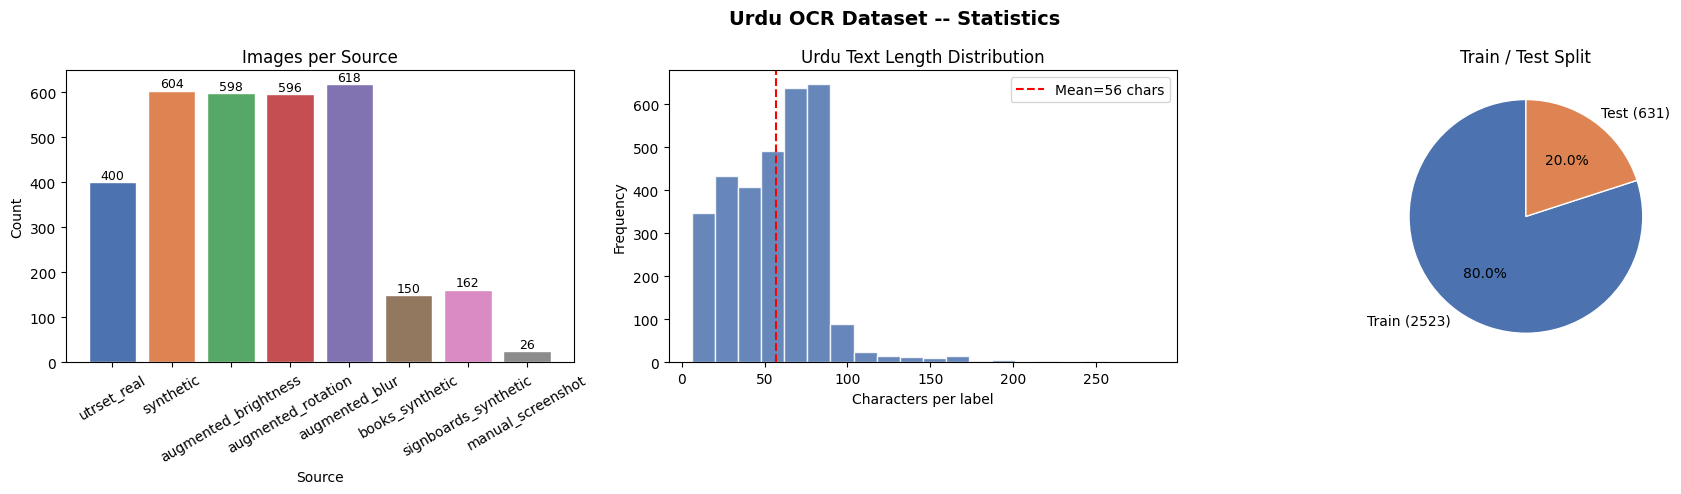

Plot saved: data/dataset_stats.png


In [32]:
def plot_dataset_stats(rows):
    """Generate three visualization plots for the dataset."""

    source_counts = {}
    for r in rows:
        src = r.get('source', 'unknown')
        source_counts[src] = source_counts.get(src, 0) + 1

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("Urdu OCR Dataset -- Statistics", fontsize=14, fontweight='bold')

    ax = axes[0]
    sources = list(source_counts.keys())
    counts  = [source_counts[s] for s in sources]
    colors  = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#937860', '#DA8BC3', '#8C8C8C']
    bars    = ax.bar(sources, counts, color=colors[:len(sources)], edgecolor='white')
    ax.set_title("Images per Source")
    ax.set_xlabel("Source")
    ax.set_ylabel("Count")
    ax.tick_params(axis='x', rotation=30)
    for bar, cnt in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                str(cnt), ha='center', va='bottom', fontsize=9)

    ax = axes[1]
    lengths = [len(r['text']) for r in rows if r.get('text')]
    ax.hist(lengths, bins=20, color='#4C72B0', edgecolor='white', alpha=0.85)
    if lengths:
        ax.axvline(sum(lengths)/len(lengths), color='red', linestyle='--',
                   linewidth=1.5, label=f"Mean={sum(lengths)//len(lengths)} chars")
    ax.set_title("Urdu Text Length Distribution")
    ax.set_xlabel("Characters per label")
    ax.set_ylabel("Frequency")
    ax.legend()

    ax = axes[2]
    split_counts = {'train': 0, 'test': 0}
    for r in rows:
        if r.get('split') in split_counts:
            split_counts[r['split']] += 1
    ax.pie(
        split_counts.values(),
        labels=[f"Train ({split_counts['train']})", f"Test ({split_counts['test']})"],
        colors=['#4C72B0', '#DD8452'],
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops={'edgecolor': 'white'}
    )
    ax.set_title("Train / Test Split")

    plt.tight_layout()
    plt.savefig("data/dataset_stats.png", dpi=120, bbox_inches='tight')
    plt.show()
    print("Plot saved: data/dataset_stats.png")

plot_dataset_stats(valid_rows)

/tmp/ipykernel_1026/2127771623.py:25: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1026/2127771623.py:25: UserWarning: Matplotlib currently does not support Arabic natively.
  plt.tight_layout()
/tmp/ipykernel_1026/2127771623.py:25: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1026/2127771623.py:26: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  plt.savefig("data/sample_grid.png", dpi=120, bbox_inches='tight')
/tmp/ipykernel_1026/2127771623.py:26: UserWarning: Matplotlib currently does not support Arabic natively.
  plt.savefig("data/sample_grid.png", dpi=120, bbox_inches='tight')
/tmp/ipykernel_1026/2127771623.py:26: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  plt.savefig("data/sample_grid.png", dpi=120, bbox_inches='tight')
/usr/local/lib/py

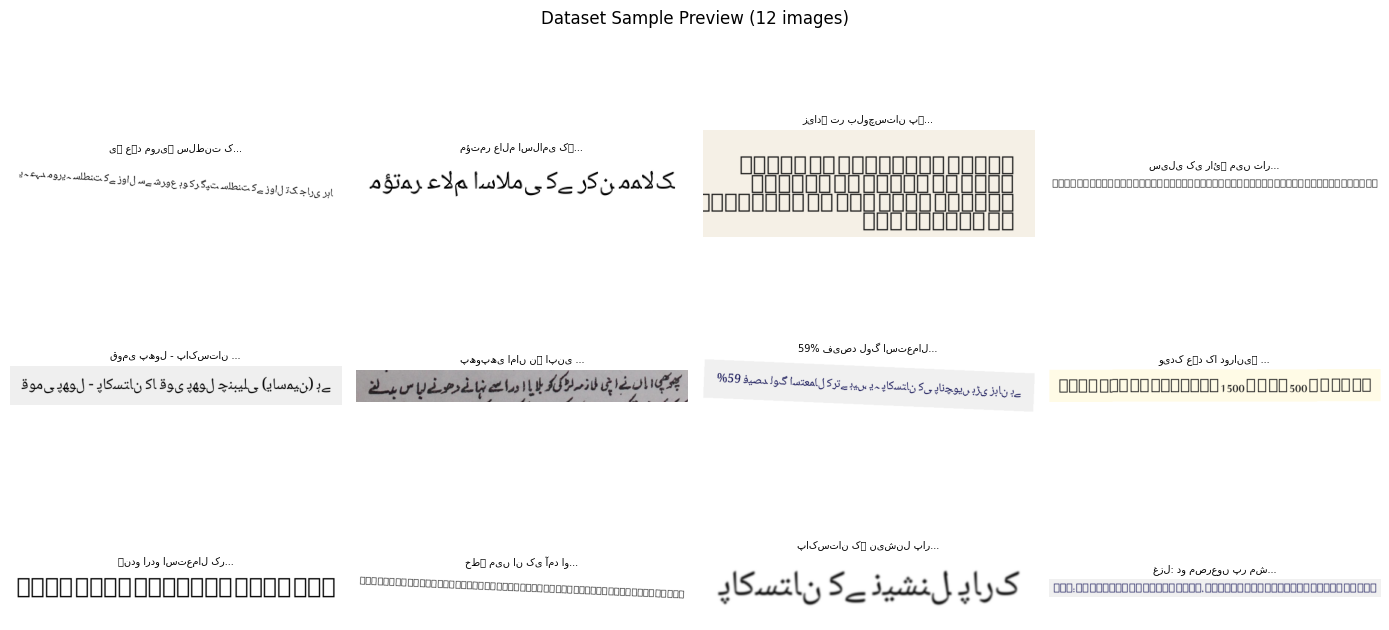

Grid saved: data/sample_grid.png


In [33]:
def plot_sample_grid(rows, n=12):
    """Show a grid of n randomly sampled images from the dataset."""
    sample = random.sample([r for r in rows if is_valid_image(r['image'])],
                           min(n, len(rows)))

    cols = 4
    rows_count = (len(sample) + cols - 1) // cols
    fig, axes = plt.subplots(rows_count, cols,
                             figsize=(cols * 3.5, rows_count * 2.5))
    axes = axes.flatten()

    for i, row in enumerate(sample):
        img = Image.open(row['image'])
        axes[i].imshow(img, cmap='gray' if img.mode == 'L' else None)
        axes[i].set_title(
            row['text'][:20] + ('...' if len(row['text']) > 20 else ''),
            fontsize=7
        )
        axes[i].axis('off')

    for j in range(len(sample), len(axes)):
        axes[j].axis('off')

    fig.suptitle(f"Dataset Sample Preview ({len(sample)} images)", fontsize=12)
    plt.tight_layout()
    plt.savefig("data/sample_grid.png", dpi=120, bbox_inches='tight')
    plt.show()
    print("Grid saved: data/sample_grid.png")

plot_sample_grid(valid_rows, n=12)

## 13. Final Summary

In [34]:
with open(LABELS_CSV, 'r', encoding='utf-8') as f:
    all_final = list(csv.DictReader(f))

with open(TRAIN_CSV, 'r', encoding='utf-8') as f:
    train_final = list(csv.DictReader(f))

with open(TEST_CSV, 'r', encoding='utf-8') as f:
    test_final = list(csv.DictReader(f))

source_summary = {}
for r in all_final:
    src = r.get('source', 'unknown')
    source_summary[src] = source_summary.get(src, 0) + 1

print("=" * 50)
print("  URDU OCR DATASET (v2) -- FINAL SUMMARY")
print("=" * 50)
print(f"  Total labeled images : {len(all_final)}")
print(f"  Training set         : {len(train_final)}")
print(f"  Test set             : {len(test_final)}")
print()
print("  Breakdown by source:")
for src, cnt in source_summary.items():
    print(f"    {src:<25} {cnt}")
print()
print("  Output files (local):")
print(f"    {LABELS_CSV}")
print(f"    {TRAIN_CSV}")
print(f"    {TEST_CSV}")
print(f"    data/dataset_stats.png")
print(f"    data/sample_grid.png")
print()
print("  Output files (Drive, used by Week 2/3/4/5 v2 notebooks):")
print(f"    {PROJECT_DIR}/labels.csv")
print(f"    {PROJECT_DIR}/data/")
print("=" * 50)

  URDU OCR DATASET (v2) -- FINAL SUMMARY
  Total labeled images : 3154
  Training set         : 2523
  Test set             : 631

  Breakdown by source:
    augmented_rotation        596
    augmented_blur            618
    utrset_real               400
    synthetic                 604
    augmented_brightness      598
    books_synthetic           150
    manual_screenshot         26
    signboards_synthetic      162

  Output files (local):
    data/labels.csv
    data/train.csv
    data/test.csv
    data/dataset_stats.png
    data/sample_grid.png

  Output files (Drive, used by Week 2/3/4/5 v2 notebooks):
    /content/drive/MyDrive/Urdu_OCR_Project_v2/labels.csv
    /content/drive/MyDrive/Urdu_OCR_Project_v2/data/


In [35]:
# Print complete folder structure with file counts
for root, dirs, files in os.walk('data'):
    level = root.replace('data', '').count(os.sep)
    indent = '    ' * level
    folder_name = os.path.basename(root)
    file_count = len([f for f in files if f.endswith(('.png', '.jpg', '.jpeg', '.csv'))])
    print(f'{indent}[DIR] {folder_name}/ ({file_count} files)')

    if level < 2:
        subindent = '    ' * (level + 1)
        for file in files:
            if file.endswith('.csv'):
                print(f'{subindent}[FILE] {file}')

[DIR] data/ (5 files)
    [FILE] train.csv
    [FILE] test.csv
    [FILE] labels.csv
    [DIR] raw/ (0 files)
        [DIR] books/ (150 files)
        [DIR] synthetic/ (604 files)
        [DIR] other/ (400 files)
        [DIR] signboards/ (162 files)
        [DIR] newspaper/ (26 files)
        [DIR] augmented/ (1812 files)
